Khushi Khatri BEB222 Experiment 10
Aim: Exploratory Data Analysis of a given text (Word Cloud).

Theory

Exploratory Data Analysis (EDA) is the practice of examining a dataset's
key properties -- distributions, frequencies, outliers, class balance --
before doing any modeling, so that patterns, biases, and data-quality
issues are caught early rather than discovered after a model has already
been trained on them. For text data specifically, EDA typically covers
document-length distribution, vocabulary size, word frequency, and
class-conditional differences in vocabulary (i.e. do different labels
use noticeably different words?).

1. Word Clouds

A word cloud is a visual summary of a text corpus where each word is
sized according to how often it occurs -- the more frequent a word, the
larger it appears. It is one of the fastest ways to get an intuitive,
at-a-glance sense of what a body of text is actually about, though it
should be paired with the more precise, numeric analyses below rather
than used alone, since visual size differences aren't always easy to
compare precisely.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from matplotlib import font_manager
FONT_PATH = font_manager.findfont(font_manager.FontProperties(family='DejaVu Sans'))
print('Using font:', FONT_PATH)
from wordcloud import wordcloud as _wc_module
from PIL import ImageFont as _PILImageFont
_original_transposed_font = _PILImageFont.TransposedFont
def _safe_transposed_font(font, orientation=None):
    if orientation is None:
        return font  # skip the wrapper entirely, old Pillow can't handle it
    return _original_transposed_font(font, orientation=orientation)
_wc_module.ImageFont.TransposedFont = _safe_transposed_font
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
STOPWORDS = set(stopwords.words('english'))
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 6)

Using font: /home/computer/anaconda3/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


[nltk_data] Downloading package punkt to /home/computer/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/computer/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/computer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
df = pd.read_csv('Balanced_Airbnb_Reviews_Dataset.csv')
print('Shape:', df.shape)
print('\nMissing values in key columns:')
print(df[['review_text', 'sentiment_label', 'review_rating']].isna().sum())
df[['review_id', 'review_text', 'sentiment_label', 'review_rating']].head()

Shape: (15000, 42)

Missing values in key columns:
review_text        0
sentiment_label    0
review_rating      0
dtype: int64


,review_id,review_text,sentiment_label,review_rating
0,369314882,Amazing stay! The place felt very cozy for 4 guests. Check-in was smooth and the amenities were exactly what we needed.,positive,5
1,490116563,It was okay for the price. Location in XIII Aurelia was convenient enough.,neutral,3
2,582235668,Loved every minute of it. Our superhost was super responsive and easy to communicate with. Great location in Venusti...,positive,5
3,68054683,"Decent stay overall. Some things could be improved, like cleanliness in the entire apartment.",neutral,3
4,248483824,Reasonable for a short trip. Location in Long Island City was convenient enough.,neutral,3


positive    5000
neutral     5000
negative    5000
Name: sentiment_label, dtype: int64


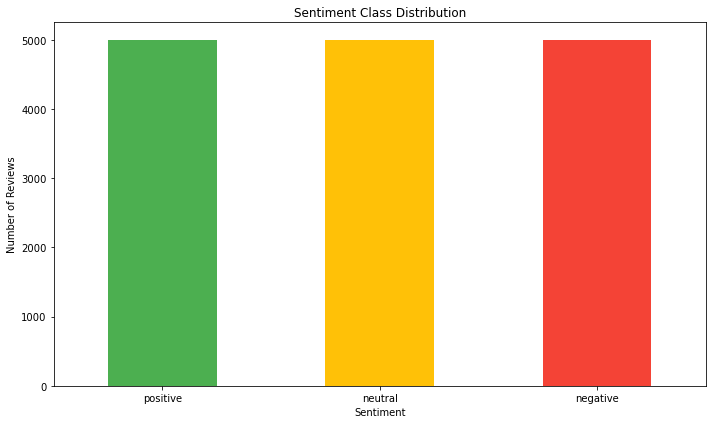

In [13]:
sentiment_counts = df['sentiment_label'].value_counts()
print(sentiment_counts)
sentiment_counts.plot(kind='bar', color=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=150)
plt.show()

Word count stats:
count    15000.000000
mean        29.129467
std          7.738227
min         11.000000
25%         25.000000
50%         28.000000
75%         36.000000
max         48.000000
Name: word_count, dtype: float64

Character count stats:
count    15000.00000
mean       152.67040
std         42.65217
min         60.00000
25%        130.00000
50%        147.00000
75%        193.00000
max        248.00000
Name: char_count, dtype: float64


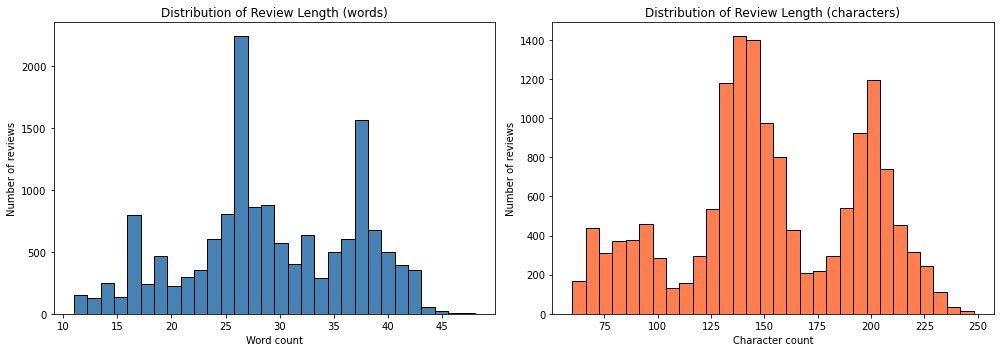

In [14]:
df['word_count'] = df['review_text'].apply(lambda t: len(word_tokenize(t)) if isinstance(t, str) else 0)
df['char_count'] = df['review_text'].apply(lambda t: len(t) if isinstance(t, str) else 0)
print('Word count stats:')
print(df['word_count'].describe())
print('\nCharacter count stats:')
print(df['char_count'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['word_count'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Review Length (words)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of reviews')
axes[1].hist(df['char_count'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Review Length (characters)')
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Number of reviews')
plt.tight_layout()
plt.savefig('eda_length_distribution.png', dpi=150)
plt.show()

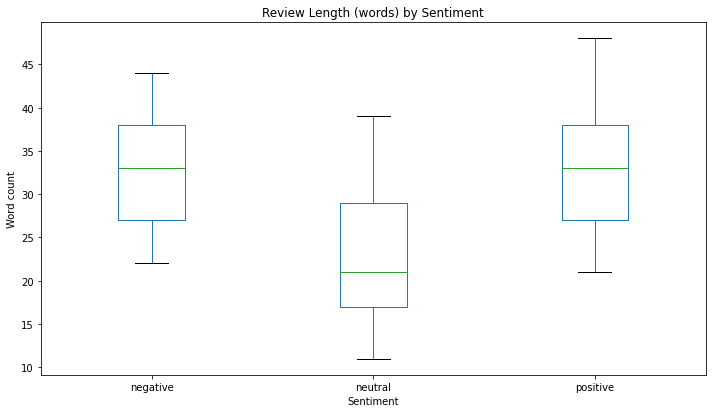

                  count     mean       std   min   25%   50%   75%   max
sentiment_label                                                         
negative         5000.0  32.2672  5.878904  22.0  27.0  33.0  38.0  44.0
neutral          5000.0  22.5636  6.400293  11.0  17.0  21.0  29.0  39.0
positive         5000.0  32.5576  6.278389  21.0  27.0  33.0  38.0  48.0


In [15]:
df.boxplot(column='word_count', by='sentiment_label', grid=False)
plt.title('Review Length (words) by Sentiment')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Word count')
plt.tight_layout()
plt.savefig('eda_length_by_sentiment.png', dpi=150)
plt.show()
print(df.groupby('sentiment_label')['word_count'].describe())

In [16]:
def get_clean_words(text):
    if not isinstance(text, str):
        return []
    return [w.lower() for w in word_tokenize(text) if w.isalpha() and w.lower() not in STOPWORDS]
all_words = [w for text in df['review_text'] for w in get_clean_words(text)]
word_freq = Counter(all_words)
print('Total tokens (after removing stopwords):', len(all_words))
print('Unique vocabulary size:', len(word_freq))
print('\nTop 20 most frequent words:')
for word, count in word_freq.most_common(20):
    print(f'{word:<15} {count}')

Total tokens (after removing stopwords): 199058
Unique vocabulary size: 497

Top 20 most frequent words:
entire          7067
apartment       7050
stay            6733
location        6144
issues          4964
exactly         4194
needed          4191
expected        3994
host            3371
would           3009
place           2723
superhost       2684
experience      2641
room            2575
clean           2550
photos          2550
suggested       2550
noisier         2544
difficult       2485
reach           2485


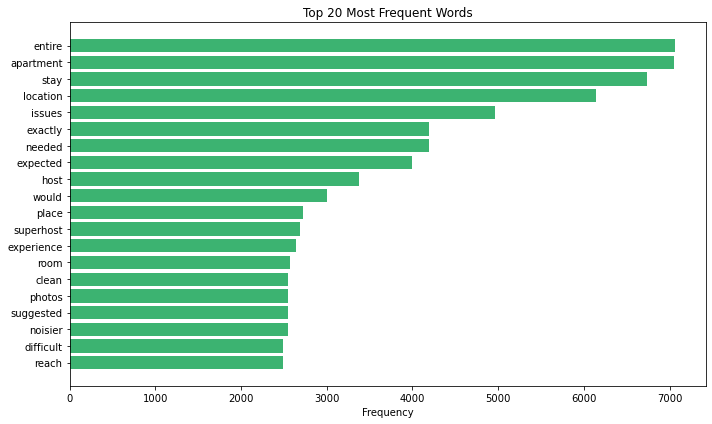

In [17]:
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)
plt.barh(words[::-1], counts[::-1], color='mediumseagreen')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150)
plt.show()

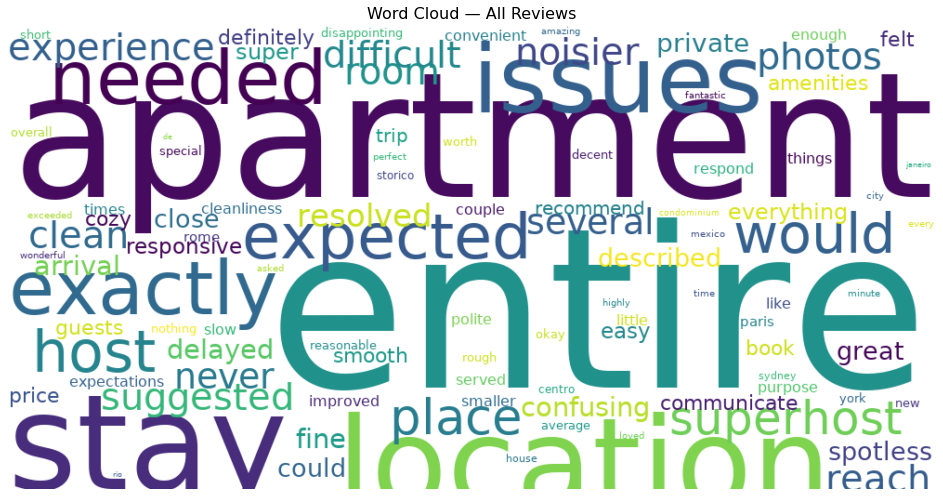

In [18]:
wordcloud_all = WordCloud(
    width=1000, height=500, background_color='white',
    max_words=100, colormap='viridis', font_path=FONT_PATH,
    prefer_horizontal=1.0,
).generate_from_frequencies(word_freq)
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=150)
plt.show()

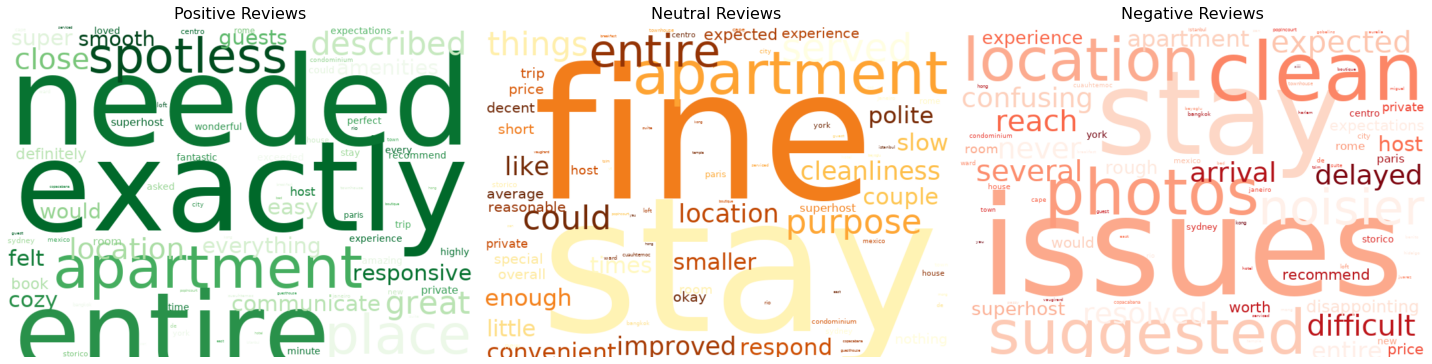

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colormaps = {'positive': 'Greens', 'neutral': 'YlOrBr', 'negative': 'Reds'}
for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    class_text = ' '.join(df[df['sentiment_label'] == label]['review_text'].dropna())
    class_words = get_clean_words(class_text)
    class_freq = Counter(class_words)
    wc = WordCloud(
        width=700, height=500, background_color='white',
        max_words=80, colormap=colormaps[label], font_path=FONT_PATH,
        prefer_horizontal=1.0,
    ).generate_from_frequencies(class_freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label.capitalize()} Reviews', fontsize=16)
    ax.axis('off')
plt.tight_layout()
plt.savefig('wordcloud_by_sentiment.png', dpi=150)
plt.show()

In [20]:
def top_words_for_class(label, n=15):
    class_text = ' '.join(df[df['sentiment_label'] == label]['review_text'].dropna())
    return Counter(get_clean_words(class_text)).most_common(n)
for label in ['positive', 'neutral', 'negative']:
    print(f'Top words in {label.upper()} reviews:')
    for word, count in top_words_for_class(label):
        print(f'   {word:<15} {count}')
    print()

Top words in POSITIVE reviews:
   exactly         4194
   needed          4191
   entire          3067
   apartment       3055
   place           2720
   spotless        2127
   described       2127
   great           2124
   location        2124
   close           2124
   everything      2124
   super           2095
   responsive      2095
   easy            2095
   communicate     2095

Top words in NEUTRAL reviews:
   stay            2620
   fine            2434
   apartment       2160
   entire          2150
   served          1581
   purpose         1581
   things          1515
   could           1515
   improved        1515
   like            1515
   cleanliness     1515
   location        1476
   convenient      1476
   enough          1476
   polite          1475

Top words in NEGATIVE reviews:
   issues          4964
   stay            3483
   clean           2550
   photos          2550
   suggested       2550
   location        2544
   noisier         2544
   expected       

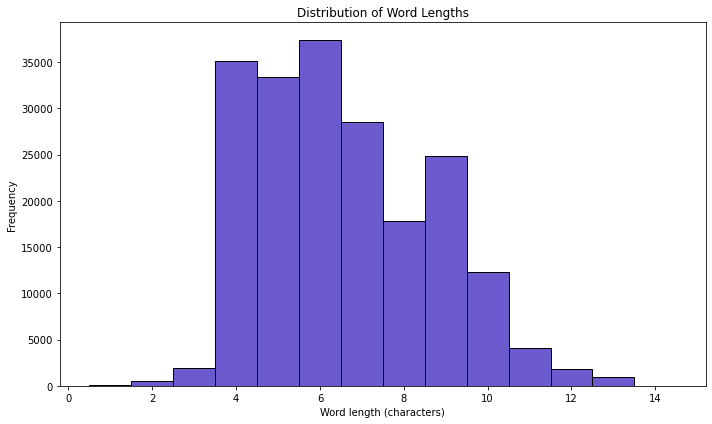

Average word length: 6.58 characters


In [21]:
word_lengths = [len(w) for w in all_words]
plt.hist(word_lengths, bins=range(1, max(word_lengths) + 2), color='slateblue',
         edgecolor='black', align='left')
plt.title('Distribution of Word Lengths')
plt.xlabel('Word length (characters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('eda_word_length.png', dpi=150)
plt.show()
print('Average word length:', round(np.mean(word_lengths), 2), 'characters')

In [22]:
print('EDA SUMMARY')
print('=' * 50)
print(f'Total reviews: {len(df)}')
print(f'Class balance: {dict(sentiment_counts)}')
print(f'Average review length: {df["word_count"].mean():.1f} words / {df["char_count"].mean():.1f} characters')
print(f'Vocabulary size (unique, non-stopword tokens): {len(word_freq)}')
print(f'Most frequent overall word: "{word_freq.most_common(1)[0][0]}" ({word_freq.most_common(1)[0][1]} occurrences)')
print(f'Average word length: {np.mean(word_lengths):.2f} characters')

EDA SUMMARY
Total reviews: 15000
Class balance: {'positive': 5000, 'neutral': 5000, 'negative': 5000}
Average review length: 29.1 words / 152.7 characters
Vocabulary size (unique, non-stopword tokens): 497
Most frequent overall word: "entire" (7067 occurrences)
Average word length: 6.58 characters


In [23]:
df.to_csv('EDA_Airbnb_Reviews.csv', index=False)
print('Saved to EDA_Airbnb_Reviews.csv')
print(df.shape)

Saved to EDA_Airbnb_Reviews.csv
(15000, 44)


In [24]:
word_freq_df = pd.DataFrame(word_freq.most_common(), columns=['word', 'frequency'])
word_freq_df.to_csv('Word_Frequencies.csv', index=False)
print('Saved to Word_Frequencies.csv')
print(word_freq_df.shape)

Saved to Word_Frequencies.csv
(497, 2)
